In [2]:
import sqlite3  
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from scipy.stats import gaussian_kde
import shapely  
from shapely import wkt  
from shapely.geometry import Polygon  
import os  
import shapely.ops
from matplotlib.pyplot import scatter

In [3]:
def process_polygon(wkt_string):
    try:
        polygon = wkt.loads(wkt_string)
        
        if polygon.geom_type == 'MultiPolygon':
            polygon = max(polygon.geoms, key=lambda p: p.area)
        
        if not polygon.is_simple:
            polygon = polygon.buffer(0)
        
        return polygon
    
    except Exception as e:
        print(f"处理多边形时出错: {e}")
        return None

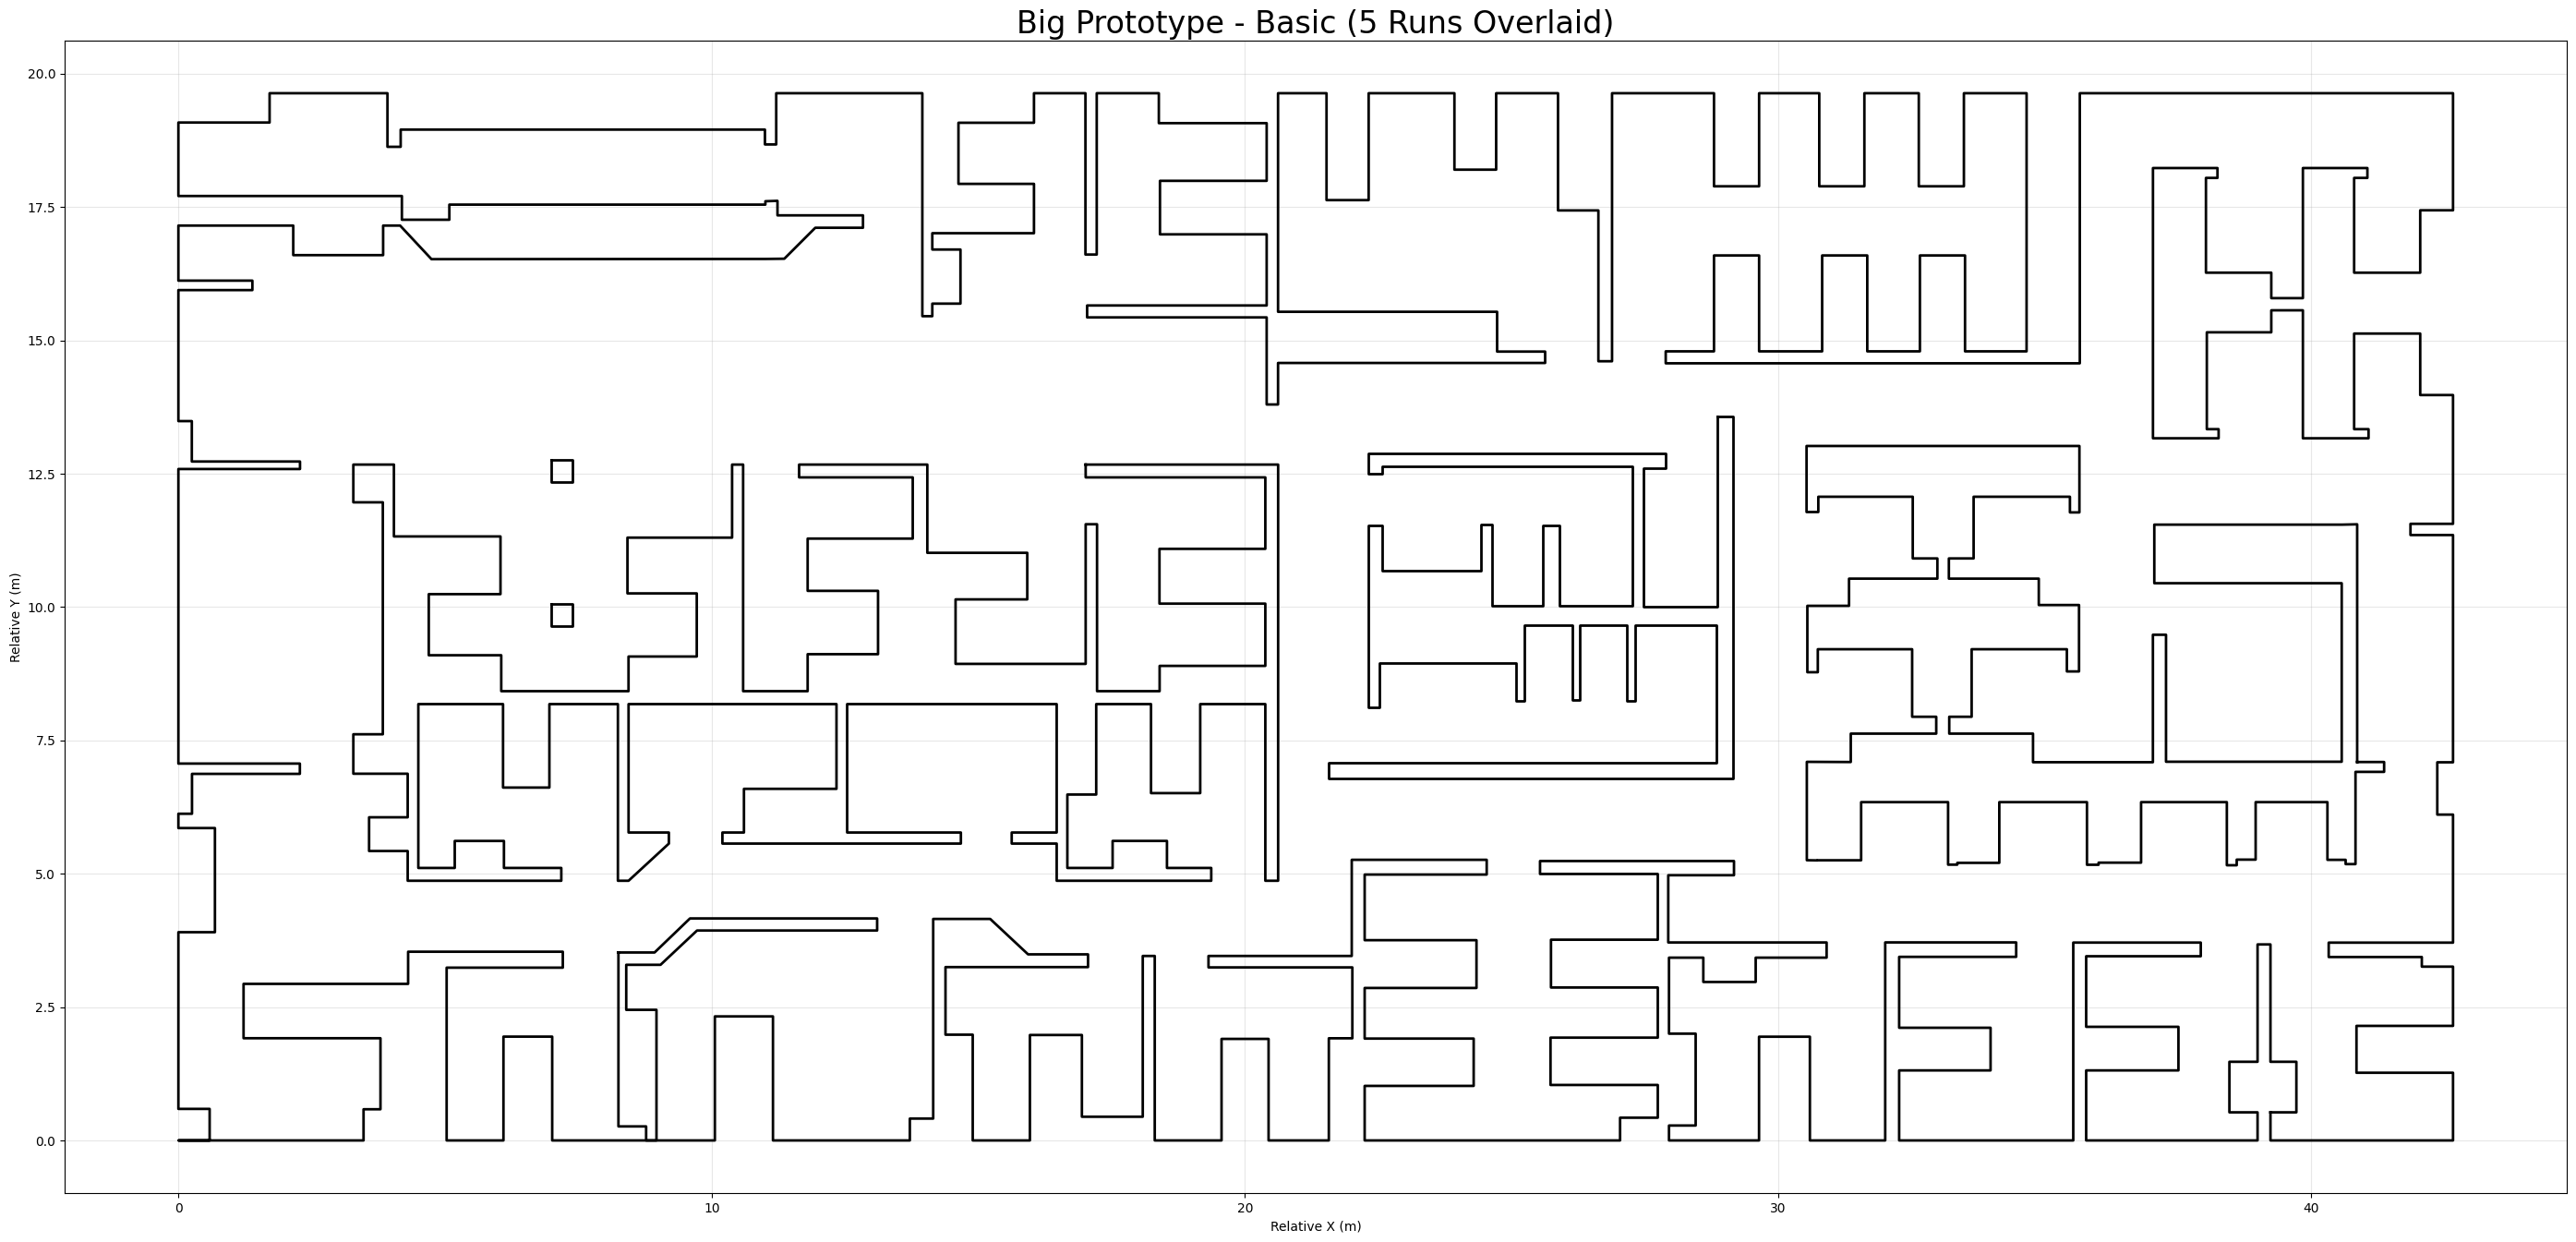

轨迹叠加统计:
宽度 1.0m: 5 次实验, 每次 57 个代理, 总计 285 条轨迹
宽度 1.2m: 5 次实验, 每次 57 个代理, 总计 285 条轨迹
宽度 1.4m: 5 次实验, 每次 57 个代理, 总计 285 条轨迹
宽度 1.6m: 5 次实验, 每次 57 个代理, 总计 285 条轨迹


In [11]:
# restore data
trajectories = {}
geometries = {}
layout = 'Exit'

# 遍历不同宽度的文件
for width in np.arange(1.0, 1.8, 0.2):
    width = round(width, 1)
    
    # store all trajectories
    all_trajectories = []
    geometry = None
    
    # 读取5次重复实验
    for run in range(5):
        filename = f"./Big_Average/{layout}/Width_{width:.1f}_{run}.sqlite"
        
        try:
            # 连接数据库
            conn = sqlite3.connect(filename)
            
            # 读取轨迹数据
            traj_df = pd.read_sql_query("SELECT * FROM trajectory_data", conn)
            
            # 只读取一次几何数据（所有重复实验的几何应该相同）
            if geometry is None:
                geom_df = pd.read_sql_query("SELECT * FROM geometry", conn)
                if not geom_df.empty:
                    geometry = process_polygon(geom_df['wkt'].iloc[0])
            
            conn.close()
            
            # 添加运行编号标识
            traj_df['run'] = run
            all_trajectories.append(traj_df)
            
        except Exception as e:
            print(f"读取 {filename} 失败: {e}")
    
    # 合并所有重复实验的轨迹
    if all_trajectories and geometry is not None:
        combined_trajectories = pd.concat(all_trajectories, ignore_index=True)
        trajectories[width] = combined_trajectories
        geometries[width] = geometry
    else:
        print(f"宽度 {width} 的数据处理失败")

# 创建子图
fig, axes = plt.subplots(
    #nrows=2, 
    #ncols=2, 
    figsize=(28, 14)
)
axes = np.atleast_1d(axes)

# 设置轨迹样式
trajectory_color = 'red'
trajectory_alpha = 0.3
trajectory_linewidth = 0.8

for ax, (width, traj_df) in zip(axes.flatten(), trajectories.items()):
    
    # 计算坐标偏移量（用于标准化显示）
    x_min = min(traj_df['pos_x'].min(), geometries[width].bounds[0])  
    y_min = min(traj_df['pos_y'].min(), geometries[width].bounds[1])  
    
    geom = geometries[width]
    
    # 绘制几何边界
    if geom.geom_type == 'Polygon':  
        x, y = geom.exterior.xy
        x = np.array(x) - x_min
        y = np.array(y) - y_min
        ax.plot(x, y, 'k-', linewidth=2, label='Boundary') 
        
        # 绘制内部孔洞（如果有）
        for interior in geom.interiors:
            x_hole, y_hole = interior.xy
            x_hole = np.array(x_hole) - x_min
            y_hole = np.array(y_hole) - y_min
            ax.plot(x_hole, y_hole, 'k-', linewidth=2)
            
    elif geom.geom_type == 'MultiPolygon':  
        for poly in geom.geoms:  
            x, y = poly.exterior.xy  
            x = np.array(x) - x_min
            y = np.array(y) - y_min 
            ax.plot(x, y, 'k-', linewidth=2)
    
    # 绘制所有代理的轨迹（包括5次重复实验）
    #for run in range(5):
        #run_data = traj_df[traj_df['run'] == run]
        
        #for agent_id in run_data['id'].unique():
            #agent_traj = run_data[run_data['id'] == agent_id]
            
            # 按帧排序确保轨迹连续
            #agent_traj = agent_traj.sort_values('frame')
            
            #ax.plot(
                #agent_traj['pos_x'] - x_min, 
                #agent_traj['pos_y'] - y_min, 
                #color=trajectory_color,
                #alpha=trajectory_alpha,
                #linewidth=trajectory_linewidth
            #)
    
    # 设置图形属性
    ax.set_title(f"Big Prototype - Basic (5 Runs Overlaid)", fontsize=24)
    ax.set_xlabel('Relative X (m)')
    ax.set_ylabel('Relative Y (m)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 添加图例（只在第一个子图）
    #if ax == axes.flatten()[0]:
        #ax.plot([], [], color=trajectory_color, alpha=trajectory_alpha, 
                #linewidth=trajectory_linewidth, label='Agent Trajectories')
        #ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'data/processed/trajectory_overlay_layout_{layout}_Basic.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印统计信息
print("轨迹叠加统计:")
for width, traj_df in trajectories.items():
    total_agents = len(traj_df.groupby(['run', 'id']))
    runs_count = len(traj_df['run'].unique())
    agents_per_run = len(traj_df[traj_df['run'] == 0]['id'].unique())
    
    print(f"宽度 {width}m: {runs_count} 次实验, 每次 {agents_per_run} 个代理, 总计 {total_agents} 条轨迹")


In [4]:
# 在绘制散点图或LineCollection之前，对速度值进行非线性映射  
def enhance_red_mapping(speed_values, global_vmin, global_vmax, power=2):  
    """  
    使用幂函数映射来突出低速（红色）区域  
    power > 1: 突出低速区域（红色）  
    power < 1: 突出高速区域（绿色）  
    """  
    # 标准化到0-1范围  
    normalized = (speed_values - global_vmin) / (global_vmax - global_vmin)  
    # 应用幂函数映射  
    mapped = np.power(normalized, power)  
    # 映射回原始范围  
    return mapped * (global_vmax - global_vmin) + global_vmin  


速度范围: 0.000 - 0.824 m/s
处理宽度 1.0m 的数据...
  - 总轨迹点: 113,094
  - 有效点: 113,094 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.552 m/s


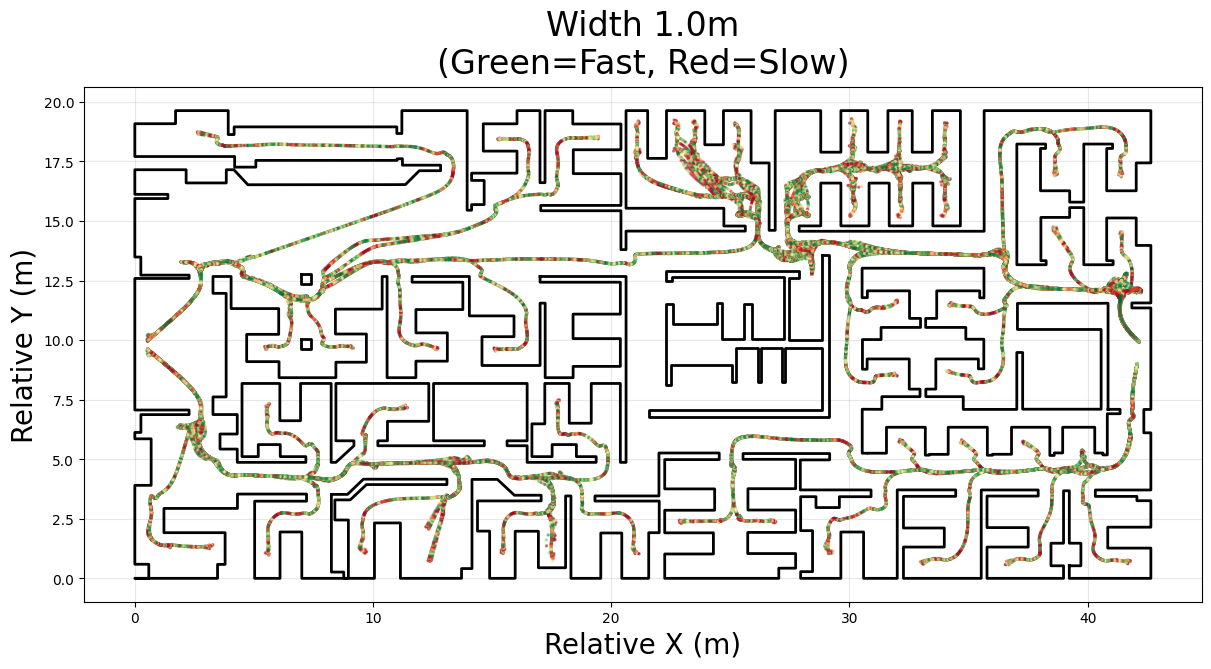

处理宽度 1.2m 的数据...
  - 总轨迹点: 106,422
  - 有效点: 106,422 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.580 m/s


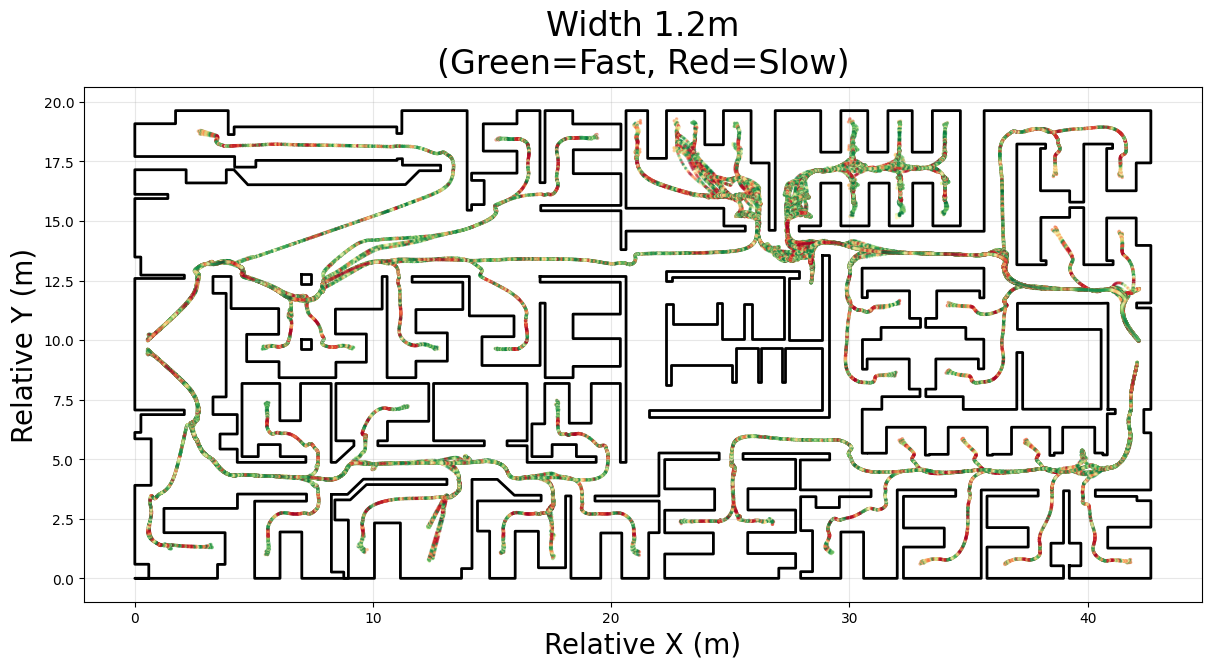

处理宽度 1.4m 的数据...
  - 总轨迹点: 104,520
  - 有效点: 104,520 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.587 m/s


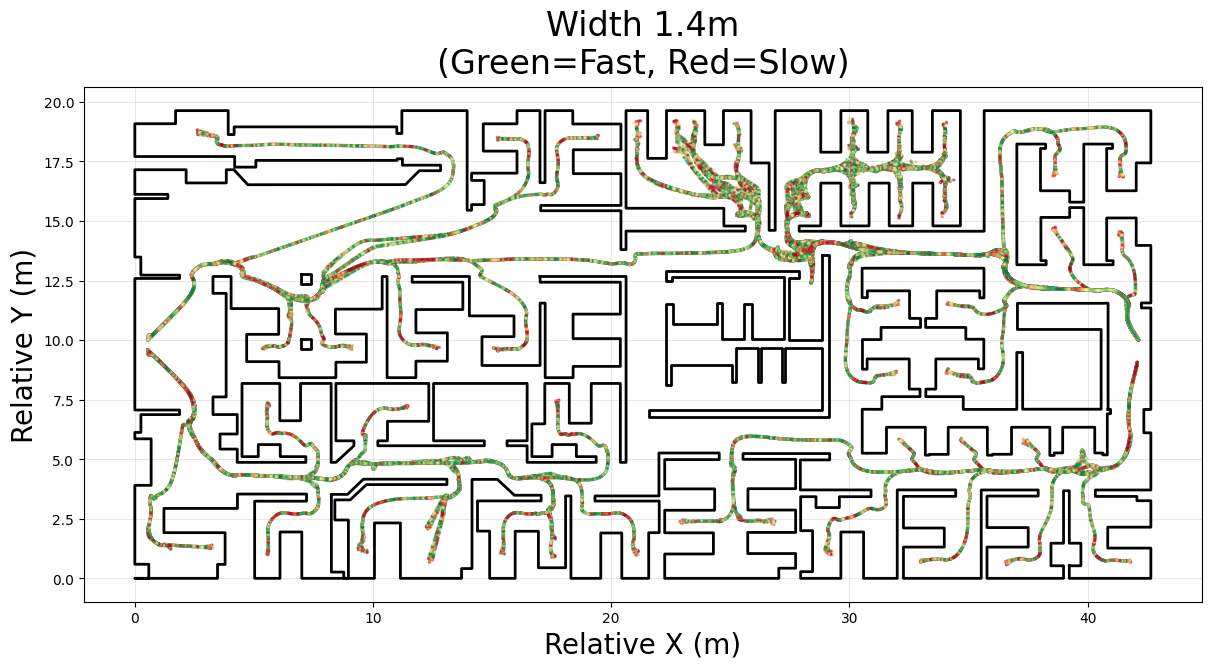

处理宽度 1.6m 的数据...
  - 总轨迹点: 102,632
  - 有效点: 102,632 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.592 m/s


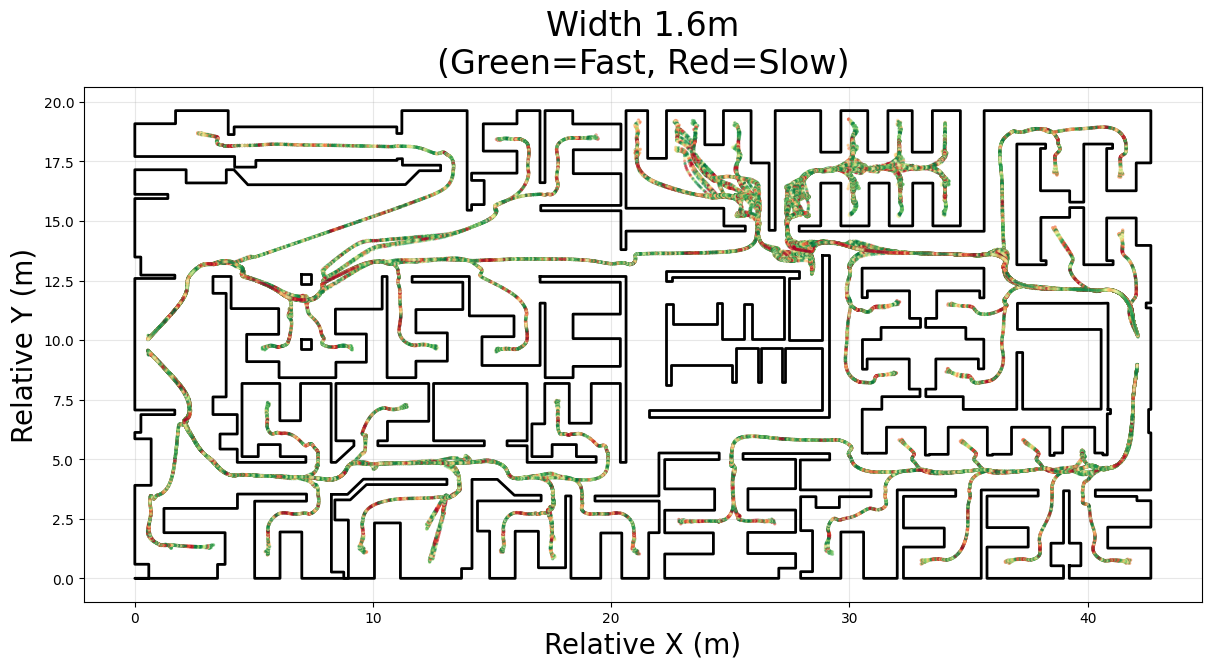


速度轨迹统计:
宽度 1.0m:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.557, 标准差=0.248
  - 速度范围: 0.001 - 3.772 m/s
  - 低速点比例(<0.5 m/s): 38.2%
宽度 1.2m:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.583, 标准差=0.234
  - 速度范围: 0.000 - 1.724 m/s
  - 低速点比例(<0.5 m/s): 33.2%
宽度 1.4m:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.590, 标准差=0.234
  - 速度范围: 0.000 - 5.747 m/s
  - 低速点比例(<0.5 m/s): 31.5%
宽度 1.6m:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.594, 标准差=0.229
  - 速度范围: 0.001 - 1.775 m/s
  - 低速点比例(<0.5 m/s): 31.0%


In [18]:
import shapely
from matplotlib.collections import LineCollection  
from shapely.geometry import Point
from shapely.geometry import MultiPolygon

# restore data
trajectories = {}
geometries = {}
layout = 'Exit'

# 遍历不同宽度的文件
for width in np.arange(1.0, 1.8, 0.2):
    width = round(width, 1)
    
    # store all trajectories
    all_trajectories = []
    geometry = None
    
    # 读取5次重复实验
    for run in range(5):
        filename = f"./Big_Average/{layout}/Width_{width:.1f}_{run}.sqlite"
        
        try:
            # 连接数据库
            conn = sqlite3.connect(filename)
            
            # 读取轨迹数据
            traj_df = pd.read_sql_query("SELECT * FROM trajectory_data", conn)
            
            # 只读取一次几何数据（所有重复实验的几何应该相同）
            if geometry is None:
                geom_df = pd.read_sql_query("SELECT * FROM geometry", conn)
                if not geom_df.empty:
                    geometry = process_polygon(geom_df['wkt'].iloc[0])
            
            conn.close()
            
            # 添加运行编号标识
            traj_df['run'] = run
            all_trajectories.append(traj_df)
            
        except Exception as e:
            print(f"读取 {filename} 失败: {e}")
    
    # 合并所有重复实验的轨迹并计算速度
    if all_trajectories and geometry is not None:
        combined_trajectories = pd.concat(all_trajectories, ignore_index=True)
        
        # 计算速度
        speeds = []
        for run in range(5):
            run_data = combined_trajectories[combined_trajectories['run'] == run]
            
            for agent_id in run_data['id'].unique():
                agent_data = run_data[run_data['id'] == agent_id].sort_values('frame')
                
                # 计算位移和时间差
                dx = agent_data['pos_x'].diff()
                dy = agent_data['pos_y'].diff()
                dt = agent_data['frame'].diff() * 0.1  # 假设每帧0.1秒
                
                # 避免除零错误
                dt = dt.replace(0, np.nan)
                
                # 计算速度
                agent_speed = np.sqrt(dx**2 + dy**2) / dt
                
                # 填充NaN值
                agent_speed = agent_speed.bfill().fillna(0)  
                
                speeds.extend(agent_speed.tolist())
        
        combined_trajectories['speed'] = speeds
        
        trajectories[width] = combined_trajectories
        geometries[width] = geometry
    else:
        print(f"宽度 {width} 的数据处理失败")

# 创建子图
#fig, axes = plt.subplots(
    #nrows=2, 
    #ncols=2, 
    #figsize=(28, 14),
    #constrained_layout=True
#)

#axes = axes.flatten()

# 计算全局速度范围（用于统一颜色映射）
all_speeds = []
for traj_df in trajectories.values():
    if 'speed' in traj_df.columns:
        valid_speeds = traj_df['speed'].dropna()
        all_speeds.extend(valid_speeds.tolist())

if all_speeds:
    # 设置全局速度范围
    global_vmin = 0.0
    global_vmax = np.percentile(all_speeds, 95)  # 使用95分位数避免极值影响
    
    print(f"速度范围: {global_vmin:.3f} - {global_vmax:.3f} m/s")
else:
    global_vmin, global_vmax = 0.0, 1.0

for idx, (width, traj_df) in enumerate(trajectories.items()):  
    # 为每个宽度创建单独的图  
    fig, ax = plt.subplots(figsize=(12, 10), constrained_layout=True)  
    
    # 计算坐标偏移量（用于标准化显示）  
    x_min = min(traj_df['pos_x'].min(), geometries[width].bounds[0])  
    y_min = min(traj_df['pos_y'].min(), geometries[width].bounds[1])  
    
    geom = geometries[width]  
    
    # 绘制几何边界  
    if geom.geom_type == 'Polygon':  
        x, y = geom.exterior.xy  
        x = np.array(x) - x_min  
        y = np.array(y) - y_min  
        ax.plot(x, y, 'k-', linewidth=2)   
        
        # 绘制内部孔洞（如果有）  
        for interior in geom.interiors:  
            x_hole, y_hole = interior.xy  
            x_hole = np.array(x_hole) - x_min  
            y_hole = np.array(y_hole) - y_min  
            ax.plot(x_hole, y_hole, 'k-', linewidth=2)  
            
    elif geom.geom_type == 'MultiPolygon':  
        for poly in geom.geoms:  
            x, y = poly.exterior.xy  
            x = np.array(x) - x_min  
            y = np.array(y) - y_min   
            ax.plot(x, y, 'k-', linewidth=2)  
    
    # **添加区域内点的过滤检查**  
    print(f"处理宽度 {width}m 的数据...")  
    
    # 创建偏移后的几何体用于检查  
    if geom.geom_type == 'Polygon':  
        shifted_geom = Polygon(  
            [(x - x_min, y - y_min) for x, y in geom.exterior.coords],  
            holes=[[(x - x_min, y - y_min) for x, y in interior.coords]   
                   for interior in geom.interiors]  
        )  
    elif geom.geom_type == 'MultiPolygon':  
        shifted_geom = MultiPolygon([  
            Polygon([(x - x_min, y - y_min) for x, y in poly.exterior.coords],  
                   holes=[[(x - x_min, y - y_min) for x, y in interior.coords]   
                          for interior in poly.interiors])  
            for poly in geom.geoms  
        ])  
    
    # 准备原始数据  
    x_coords = traj_df['pos_x'] - x_min  
    y_coords = traj_df['pos_y'] - y_min  
    speed_values = traj_df['speed'].clip(global_vmin, global_vmax)  
    
    # **检查哪些点在可行走区域内**  
    valid_mask = []  
    total_points = len(x_coords)  
    
    for i in range(total_points):  
        point = Point(x_coords.iloc[i], y_coords.iloc[i])  
        is_valid = shifted_geom.contains(point) or shifted_geom.touches(point)  
        valid_mask.append(is_valid)  
    
    valid_mask = np.array(valid_mask)  
    
    # 统计过滤结果  
    valid_count = valid_mask.sum()  
    invalid_count = len(valid_mask) - valid_count  
    
    print(f"  - 总轨迹点: {total_points:,}")  
    print(f"  - 有效点: {valid_count:,} ({valid_count/total_points*100:.1f}%)")  
    print(f"  - 无效点: {invalid_count:,} ({invalid_count/total_points*100:.1f}%)")  
    
    # **只保留有效点**  
    if valid_count > 0:  
        x_coords_valid = x_coords[valid_mask]  
        y_coords_valid = y_coords[valid_mask]  
        speed_values_valid = speed_values[valid_mask]  
        
        # 使用映射后的速度值  
        mapped_speed_values = enhance_red_mapping(speed_values_valid, global_vmin, global_vmax, power=2)  

        # 创建速度色彩散点图  
        scatter = ax.scatter(  
            x_coords_valid,   
            y_coords_valid,  
            c=mapped_speed_values,  
            cmap='RdYlGn',  
            vmin=global_vmin,  
            vmax=global_vmax,  
            s=2,  
            alpha=0.5,  
            rasterized=True  
        )  
        
        # 更新统计信息  
        avg_speed = speed_values_valid.mean()  
    else:  
        print(f"  - 警告: 宽度 {width}m 没有有效的轨迹点!")  
        avg_speed = 0  
        # 创建空的散点图以保持一致性  
        scatter = ax.scatter([], [], c=[], cmap='RdYlGn', vmin=global_vmin, vmax=global_vmax)  
    
    # 设置图形属性  
    ax.set_title(f"Width {width}m\n(Green=Fast, Red=Slow)", fontsize=24, pad=10)  
    ax.set_xlabel('Relative X (m)', fontsize=20)  
    ax.set_ylabel('Relative Y (m)', fontsize=20)  
    ax.grid(True, alpha=0.3)  
    ax.set_aspect('equal')  
    
    print(f"  - 平均速度: {avg_speed:.3f} m/s")  
    # 在循环结尾添加单独保存  
    plt.savefig(f'data/processed/speed_trajectory_{layout}_width_{width}m.png',   
                dpi=300, bbox_inches='tight')  
    plt.show()  # 如果不想显示可以注释掉  
    plt.close()  # 关闭图形释放内存  
    

# 添加颜色条
#cbar = fig.colorbar(scatter, ax=axes, orientation='vertical',   
                   #fraction=0.05, aspect=40)  
#cbar.set_label('Speed (m/s)', fontsize=12)

# 添加总标题
#fig.suptitle(f'Layout {layout} - Speed-Based Trajectory Visualization\n(Green=High Speed, Red=Low Speed/Congestion)', 
             #fontsize=14, y=0.95)

#plt.savefig(f'data/processed/speed_trajectory_layout_{layout}.png', dpi=300, bbox_inches='tight')

# 打印详细统计信息
print("\n速度轨迹统计:")
for width, traj_df in trajectories.items():
    if 'speed' in traj_df.columns:
        speeds = traj_df['speed'].dropna()
        total_agents = len(traj_df.groupby(['run', 'id']))
        runs_count = len(traj_df['run'].unique())
        agents_per_run = len(traj_df[traj_df['run'] == 0]['id'].unique())
        
        print(f"宽度 {width}m:")
        print(f"  - {runs_count} 次实验, 每次 {agents_per_run} 个代理, 总计 {total_agents} 条轨迹")
        print(f"  - 速度统计: 均值={speeds.mean():.3f}, 标准差={speeds.std():.3f}")
        print(f"  - 速度范围: {speeds.min():.3f} - {speeds.max():.3f} m/s")
        print(f"  - 低速点比例(<0.5 m/s): {(speeds < 0.5).mean()*100:.1f}%")

计算宽度组合 1.0_1.0 的速度...
计算宽度组合 1.0_1.2 的速度...
计算宽度组合 1.0_1.4 的速度...
计算宽度组合 1.0_1.6 的速度...
计算宽度组合 1.2_1.0 的速度...
计算宽度组合 1.2_1.2 的速度...
计算宽度组合 1.2_1.4 的速度...
计算宽度组合 1.2_1.6 的速度...
计算宽度组合 1.4_1.0 的速度...
计算宽度组合 1.4_1.2 的速度...
计算宽度组合 1.4_1.4 的速度...
计算宽度组合 1.4_1.6 的速度...
计算宽度组合 1.6_1.0 的速度...
计算宽度组合 1.6_1.2 的速度...
计算宽度组合 1.6_1.4 的速度...
计算宽度组合 1.6_1.6 的速度...
速度范围: 0.000 - 0.820 m/s
处理宽度组合 1.0_1.0 的数据...
  - 总轨迹点: 105,278
  - 有效点: 105,278 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.579 m/s


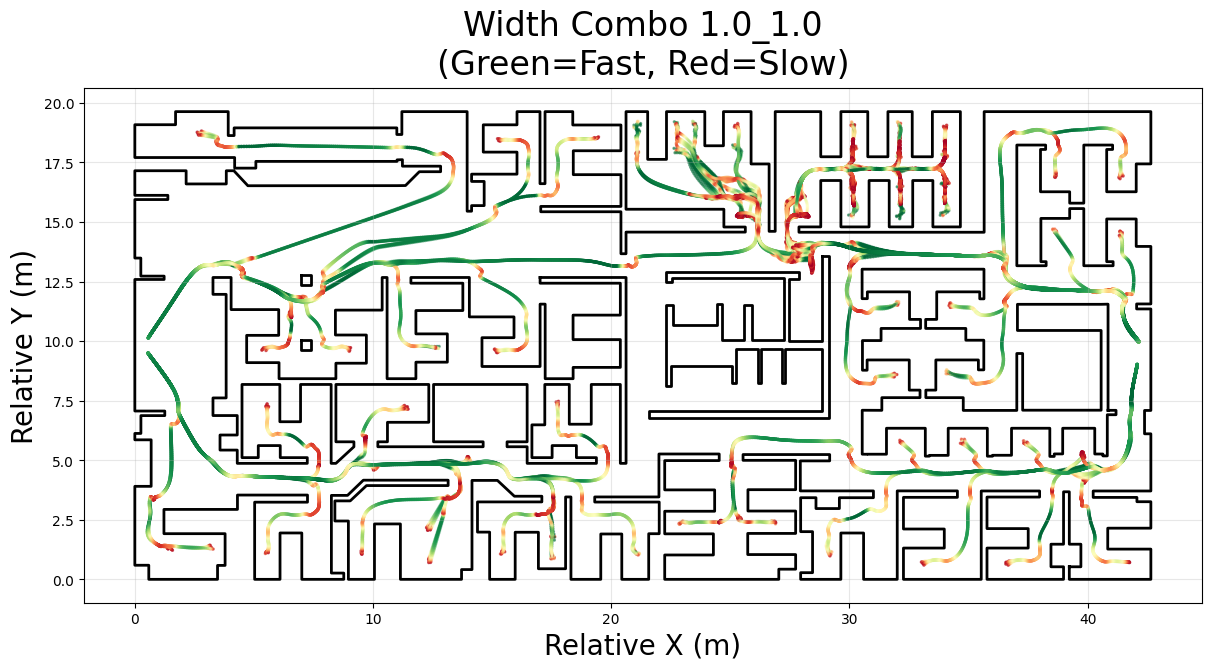

处理宽度组合 1.0_1.2 的数据...
  - 总轨迹点: 102,207
  - 有效点: 102,207 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.594 m/s


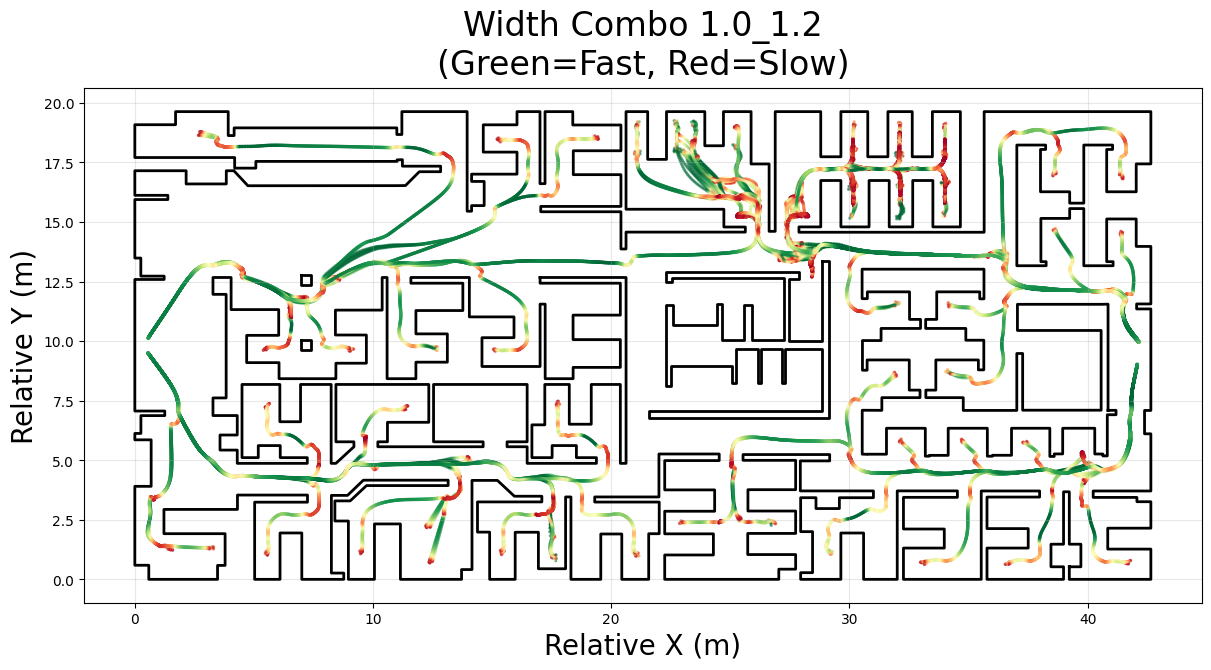

处理宽度组合 1.0_1.4 的数据...
  - 总轨迹点: 101,917
  - 有效点: 101,917 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.596 m/s


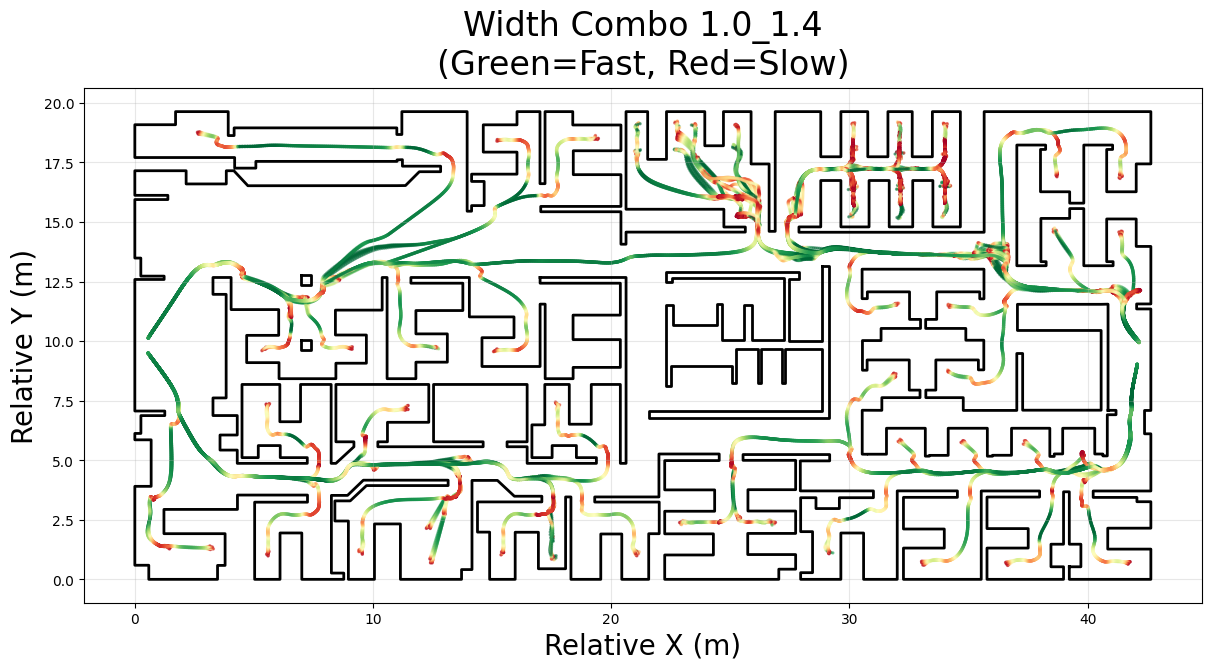

处理宽度组合 1.0_1.6 的数据...
  - 总轨迹点: 102,036
  - 有效点: 102,036 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.594 m/s


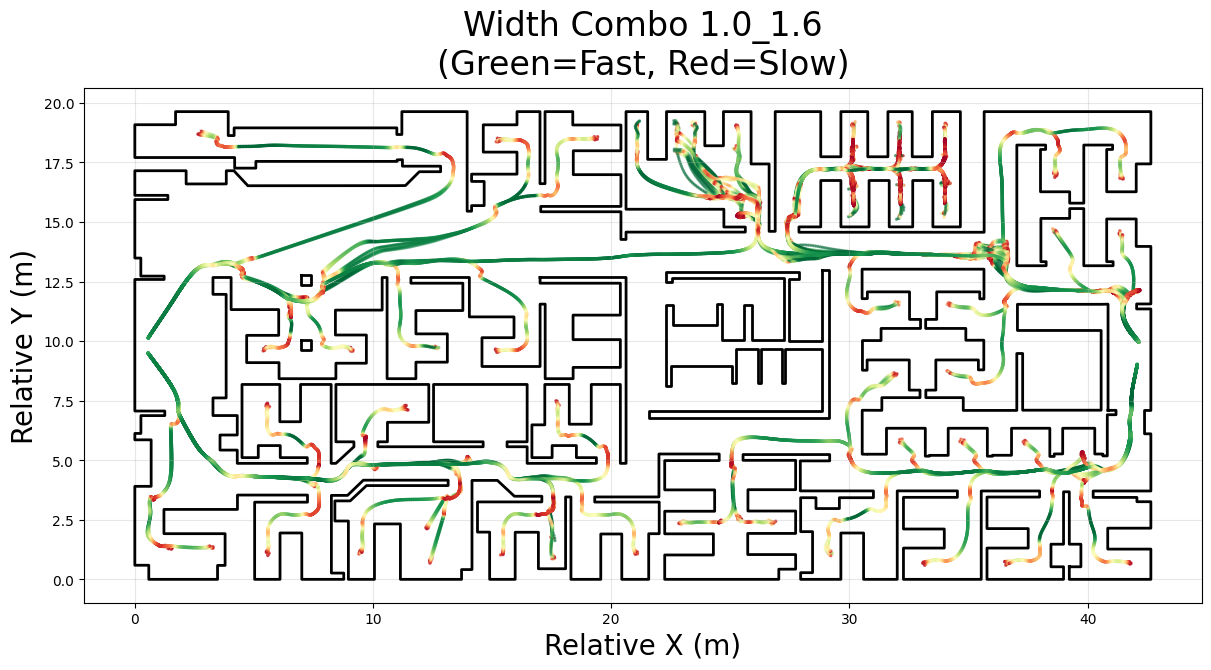

处理宽度组合 1.2_1.0 的数据...
  - 总轨迹点: 104,135
  - 有效点: 104,135 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.581 m/s


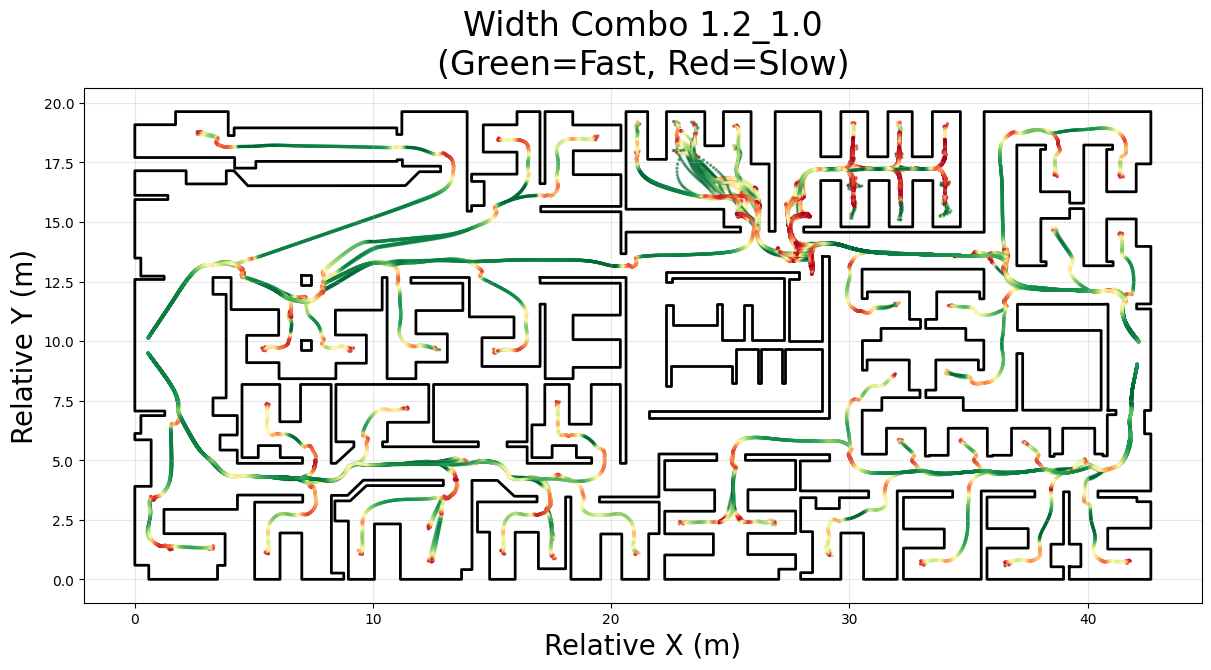

处理宽度组合 1.2_1.2 的数据...
  - 总轨迹点: 82,589
  - 有效点: 82,587 (100.0%)
  - 无效点: 2 (0.0%)
  - 平均速度: 0.587 m/s


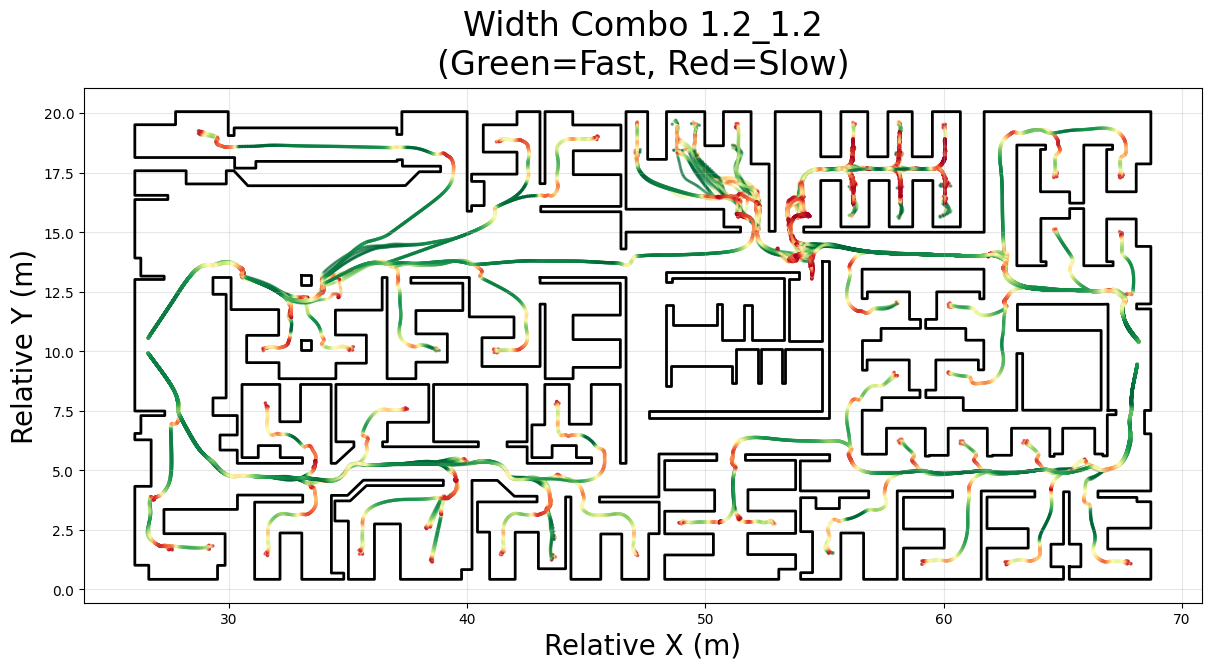

处理宽度组合 1.2_1.4 的数据...
  - 总轨迹点: 100,691
  - 有效点: 100,691 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.599 m/s


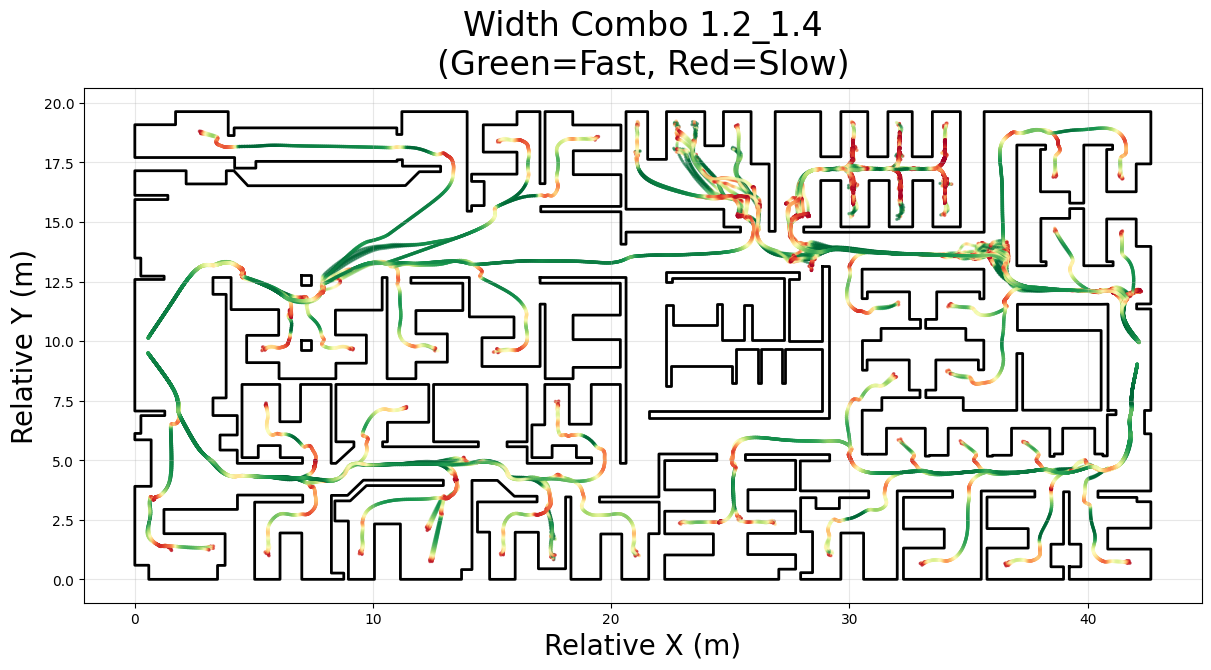

处理宽度组合 1.2_1.6 的数据...
  - 总轨迹点: 100,423
  - 有效点: 100,423 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.599 m/s


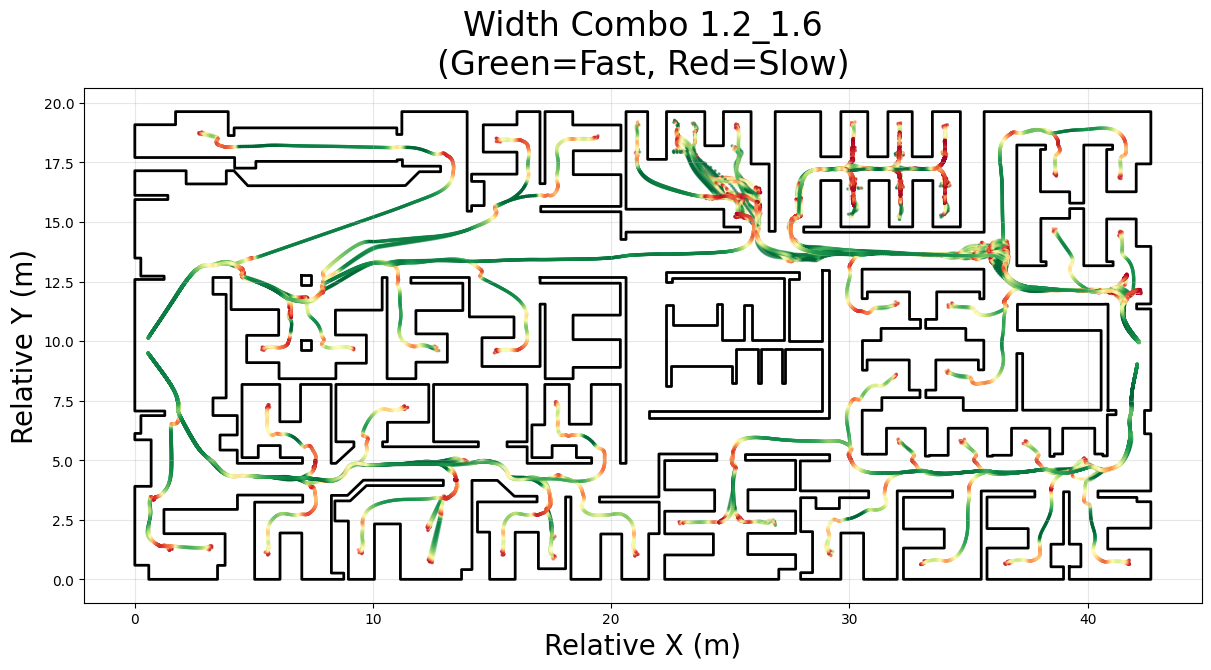

处理宽度组合 1.4_1.0 的数据...
  - 总轨迹点: 84,926
  - 有效点: 84,924 (100.0%)
  - 无效点: 2 (0.0%)
  - 平均速度: 0.569 m/s


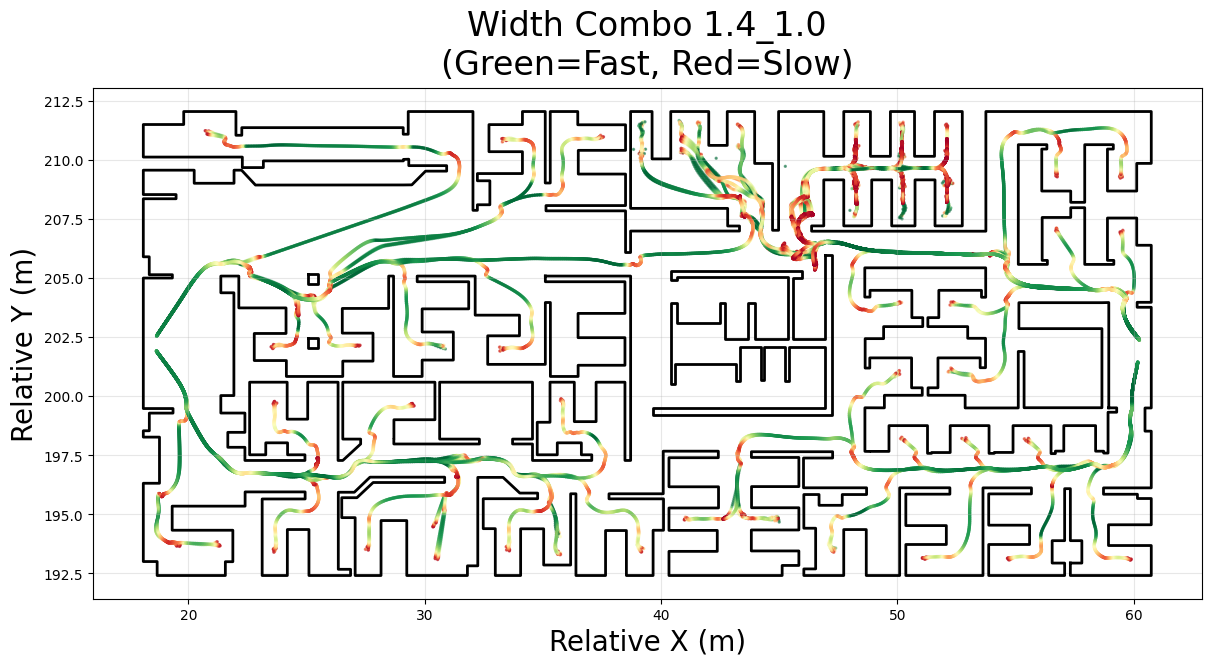

处理宽度组合 1.4_1.2 的数据...
  - 总轨迹点: 102,202
  - 有效点: 102,202 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.588 m/s


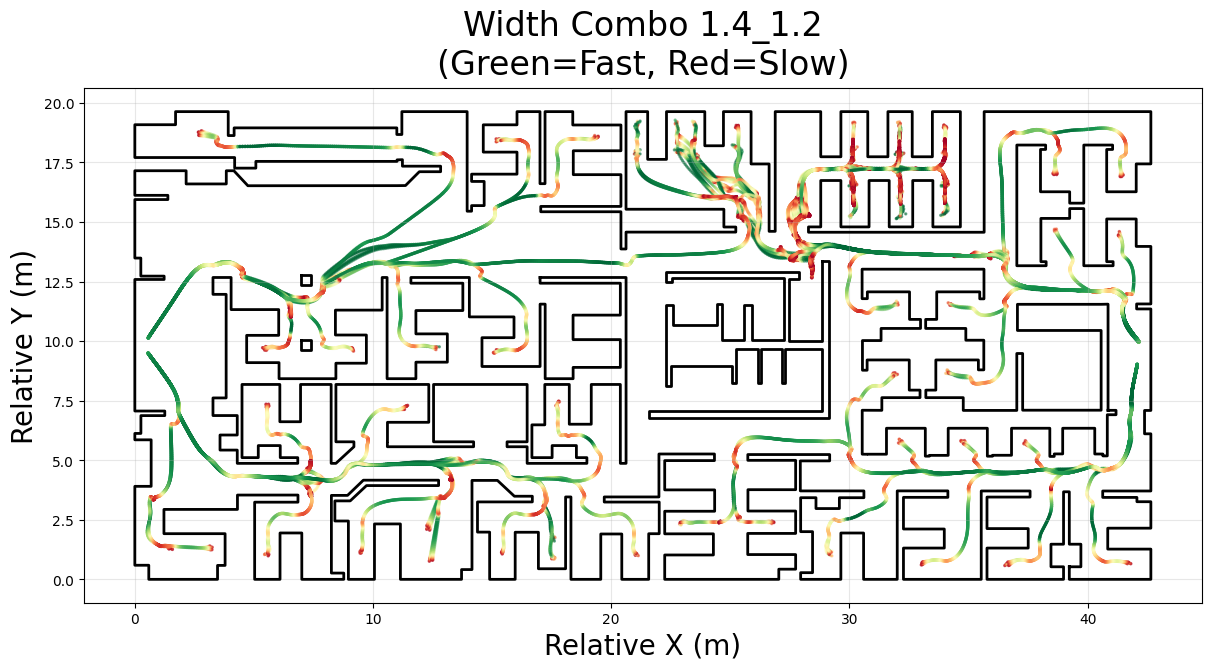

处理宽度组合 1.4_1.4 的数据...
  - 总轨迹点: 100,833
  - 有效点: 100,833 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.595 m/s


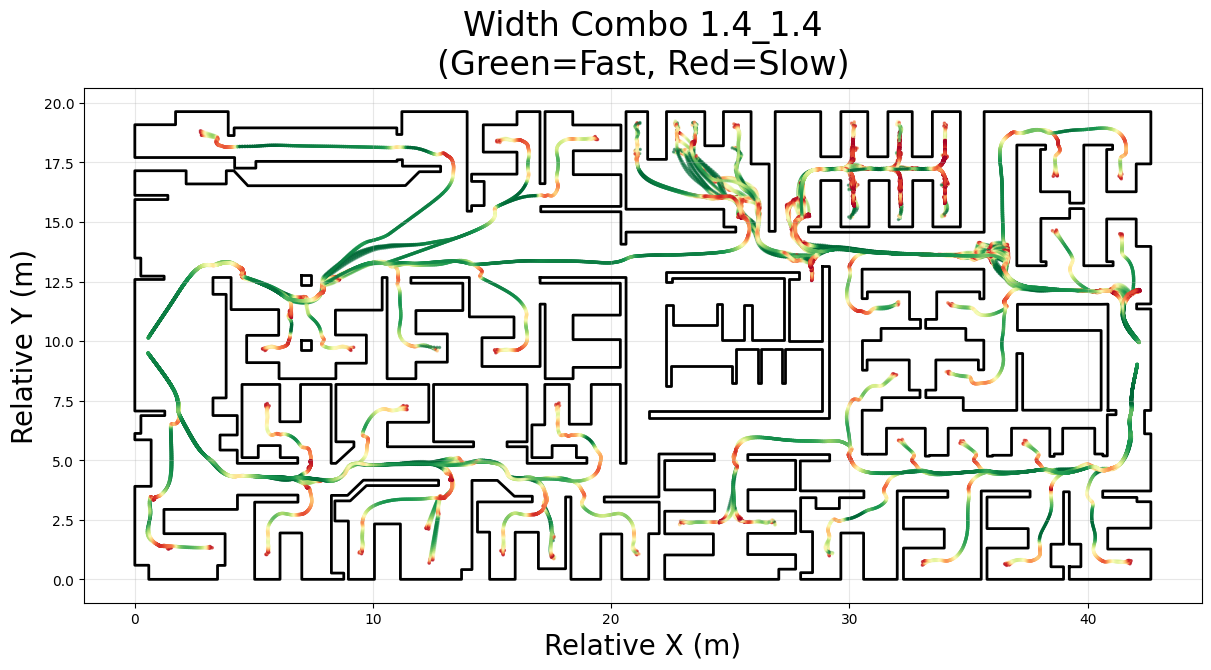

处理宽度组合 1.4_1.6 的数据...
  - 总轨迹点: 99,828
  - 有效点: 99,828 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.598 m/s


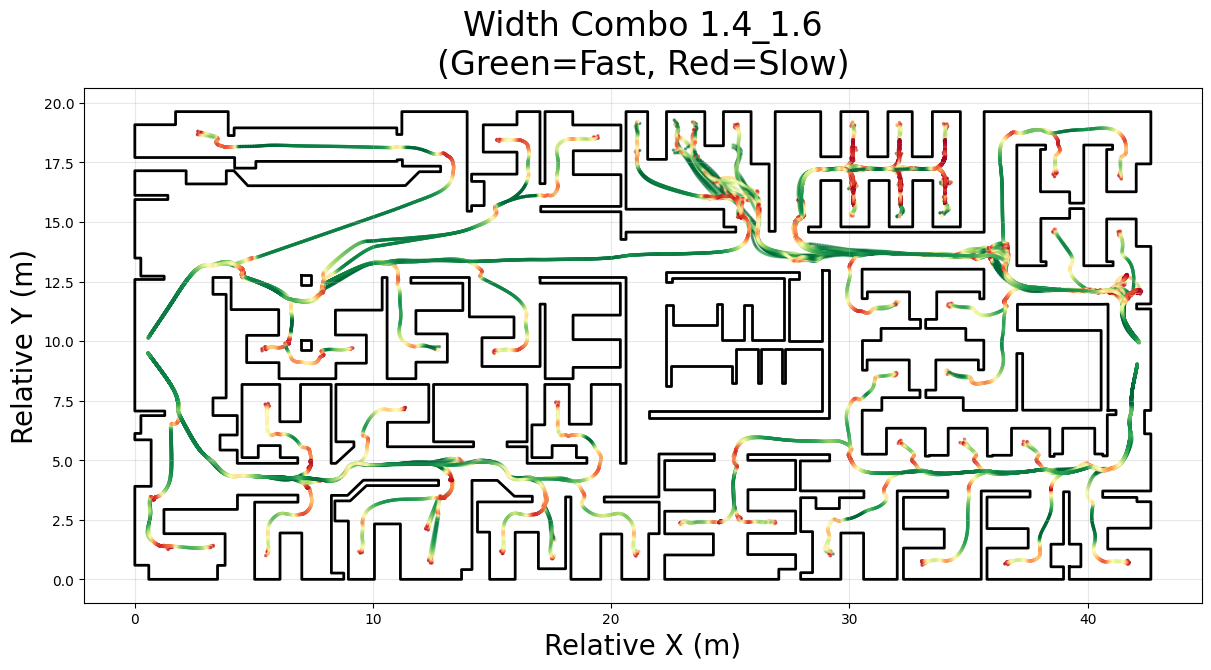

处理宽度组合 1.6_1.0 的数据...
  - 总轨迹点: 102,929
  - 有效点: 102,929 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.581 m/s


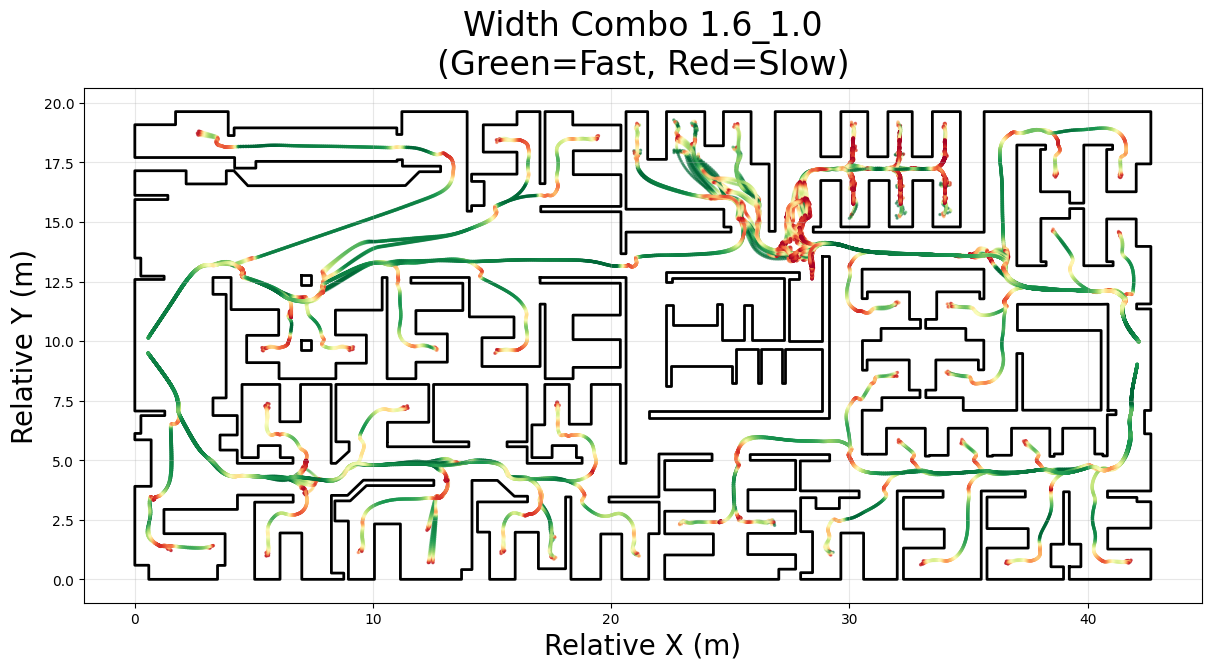

处理宽度组合 1.6_1.2 的数据...
  - 总轨迹点: 103,206
  - 有效点: 103,206 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.581 m/s


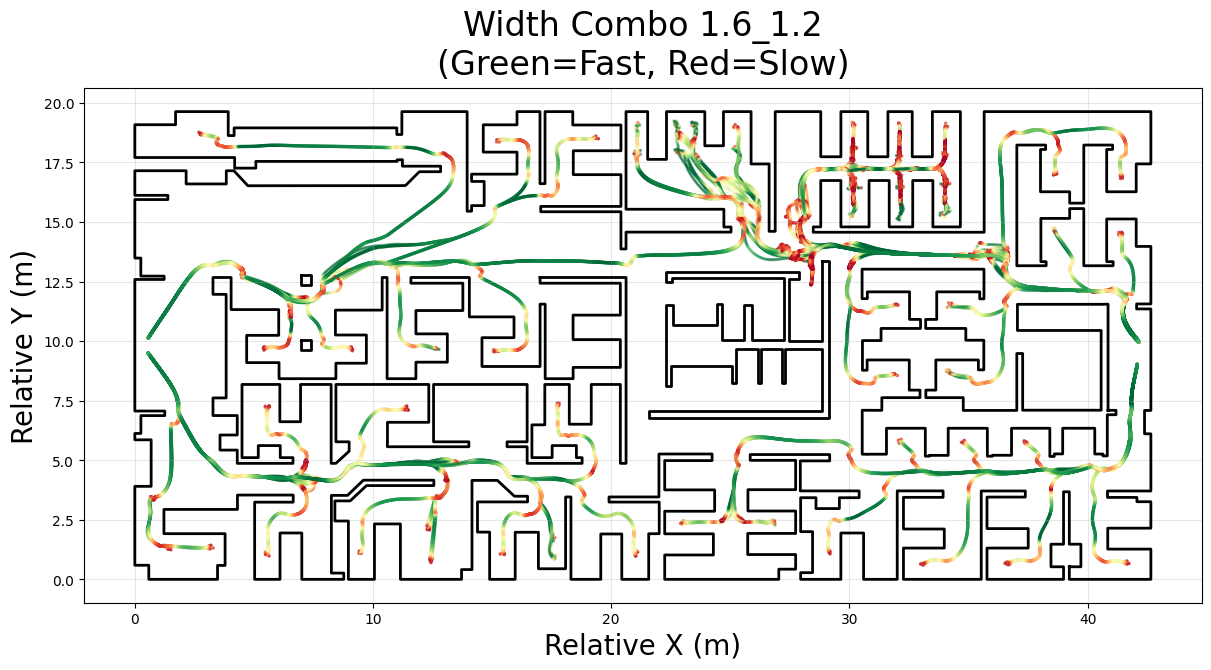

处理宽度组合 1.6_1.4 的数据...
  - 总轨迹点: 101,496
  - 有效点: 101,496 (100.0%)
  - 无效点: 0 (0.0%)
  - 平均速度: 0.590 m/s


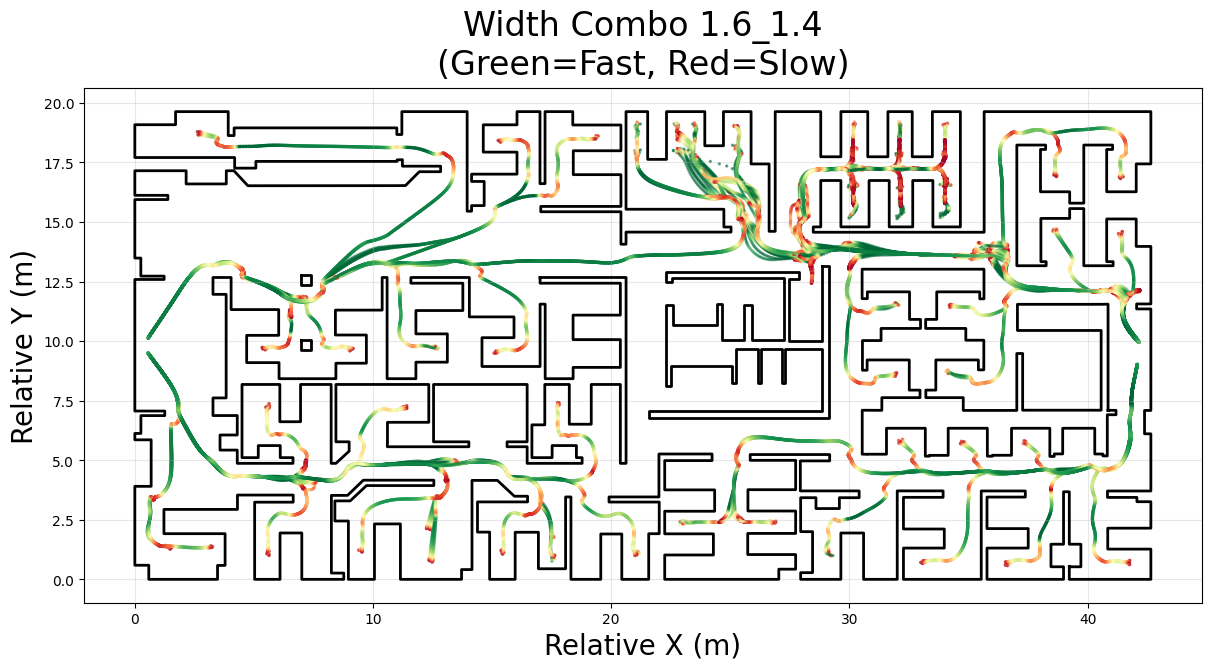

处理宽度组合 1.6_1.6 的数据...
  - 总轨迹点: 81,250
  - 有效点: 81,249 (100.0%)
  - 无效点: 1 (0.0%)
  - 平均速度: 0.590 m/s


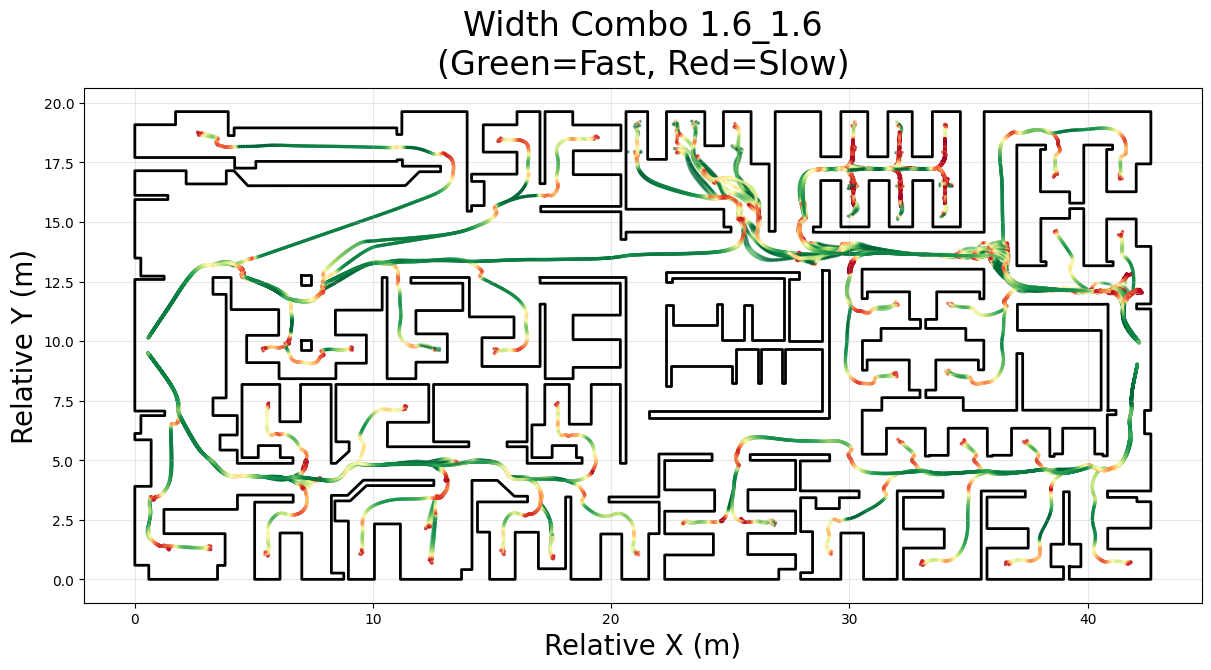


速度轨迹统计:
宽度组合 1.0_1.0:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.582, 标准差=0.243
  - 速度范围: 0.000 - 1.607 m/s
  - 低速点比例(<0.5 m/s): 32.8%
宽度组合 1.0_1.2:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.596, 标准差=0.234
  - 速度范围: 0.000 - 2.021 m/s
  - 低速点比例(<0.5 m/s): 29.8%
宽度组合 1.0_1.4:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.599, 标准差=0.231
  - 速度范围: 0.000 - 1.992 m/s
  - 低速点比例(<0.5 m/s): 29.1%
宽度组合 1.0_1.6:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.596, 标准差=0.235
  - 速度范围: 0.000 - 1.718 m/s
  - 低速点比例(<0.5 m/s): 29.8%
宽度组合 1.2_1.0:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.585, 标准差=0.243
  - 速度范围: 0.000 - 3.178 m/s
  - 低速点比例(<0.5 m/s): 32.6%
宽度组合 1.2_1.2:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.603, 标准差=2.604
  - 速度范围: 0.000 - 527.949 m/s
  - 低速点比例(<0.5 m/s): 31.4%
宽度组合 1.2_1.4:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.602, 标准差=0.227
  - 速度范围: 0.000 - 1.975 m/s
  - 低速点比例(<0.5 m/s): 28.9%
宽度组合 1.2_1.6:
  - 5 次实验, 每次 57 个代理, 总计 285 条轨迹
  - 速度统计: 均值=0.602

In [23]:
import shapely
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from matplotlib.collections import LineCollection  
from shapely.geometry import Point, MultiPolygon, Polygon

# 添加缺少的函数定义
def enhance_red_mapping(speed_values, vmin, vmax, power=2):
    """增强红色映射函数"""
    normalized = (speed_values - vmin) / (vmax - vmin)
    return np.power(normalized, power) * (vmax - vmin) + vmin

def process_polygon(wkt_string):
    """处理WKT字符串，返回Shapely几何对象"""
    from shapely import wkt
    return wkt.loads(wkt_string)

# restore data
trajectories = {}
geometries = {}
layout = 'MultiRoom'

width1_values = np.arange(1.0, 1.8, 0.2)  
width2_values = np.arange(1.0, 1.8, 0.2)  

# 遍历两个宽度参数的组合  
for width1 in width1_values:  
    width1 = round(width1, 1)  
    for width2 in width2_values:  
        width2 = round(width2, 1)  
        
        # 创建组合键  
        width_key = f"{width1}_{width2}"  
        
        # store all trajectories  
        all_trajectories = []  
        geometry = None  
        
        # 读取5次重复实验  
        for run in range(5):  
            filename = f"./Big_Average/{layout}/Width_{width1:.1f}_{width2:.1f}_{run}.sqlite"  
            
            try:  
                # 连接数据库  
                conn = sqlite3.connect(filename)  
                
                # 读取轨迹数据  
                traj_df = pd.read_sql_query("SELECT * FROM trajectory_data", conn)  
                
                # 只读取一次几何数据（所有重复实验的几何应该相同）  
                if geometry is None:  
                    geom_df = pd.read_sql_query("SELECT * FROM geometry", conn)  
                    if not geom_df.empty:  
                        geometry = process_polygon(geom_df['wkt'].iloc[0])  
                
                conn.close()  
                
                # 添加运行编号标识  
                traj_df['run'] = run  
                all_trajectories.append(traj_df)  
                
            except Exception as e:  
                print(f"读取 {filename} 失败: {e}")  
        
        # 修复：将速度计算移到这里，每个宽度组合单独处理
        if all_trajectories and geometry is not None:  
            combined_trajectories = pd.concat(all_trajectories, ignore_index=True)  
            
            # 计算速度
            print(f"计算宽度组合 {width_key} 的速度...")
            
            # 初始化速度列
            combined_trajectories['speed'] = 0.0
            
            # 计算速度
            for run in range(5):
                run_data = combined_trajectories[combined_trajectories['run'] == run]
                if run_data.empty:
                    continue
                    
                for agent_id in run_data['id'].unique():
                    agent_mask = (combined_trajectories['run'] == run) & (combined_trajectories['id'] == agent_id)
                    agent_data = combined_trajectories[agent_mask].sort_values('frame')
                    
                    if len(agent_data) < 2:
                        continue
                        
                    # 计算位移和时间差
                    dx = agent_data['pos_x'].diff()
                    dy = agent_data['pos_y'].diff()
                    dt = agent_data['frame'].diff() * 0.1  # 假设每帧0.1秒
                    
                    # 避免除零错误
                    dt = dt.replace(0, np.nan)
                    
                    # 计算速度
                    agent_speed = np.sqrt(dx**2 + dy**2) / dt
                    
                    # 填充NaN值
                    agent_speed = agent_speed.bfill().fillna(0)
                    
                    # 直接赋值到对应位置
                    combined_trajectories.loc[agent_mask, 'speed'] = agent_speed.values
            
            # 存储处理后的数据
            trajectories[width_key] = combined_trajectories  
            geometries[width_key] = geometry  
        else:  
            print(f"宽度组合 {width_key} 的数据处理失败")  

# 计算全局速度范围（用于统一颜色映射）
all_speeds = []
for traj_df in trajectories.values():
    if 'speed' in traj_df.columns:
        valid_speeds = traj_df['speed'].dropna()
        all_speeds.extend(valid_speeds.tolist())

if all_speeds:
    # 设置全局速度范围
    global_vmin = 0.0
    global_vmax = np.percentile(all_speeds, 95)  # 使用95分位数避免极值影响
    
    print(f"速度范围: {global_vmin:.3f} - {global_vmax:.3f} m/s")
else:
    global_vmin, global_vmax = 0.0, 1.0

# 修复：使用正确的变量名
for idx, (width_combo, traj_df) in enumerate(trajectories.items()):  
    # 为每个宽度组合创建单独的图  
    fig, ax = plt.subplots(figsize=(12, 10), constrained_layout=True)  
    
    # 验证数据
    if 'speed' not in traj_df.columns:
        print(f"宽度组合 {width_combo} 缺少速度列，跳过")
        plt.close()
        continue
    
    # 计算坐标偏移量（用于标准化显示）  
    x_min = min(traj_df['pos_x'].min(), geometries[width_combo].bounds[0])  
    y_min = min(traj_df['pos_y'].min(), geometries[width_combo].bounds[1])  
    
    geom = geometries[width_combo]  
    
    # 绘制几何边界  
    if geom.geom_type == 'Polygon':  
        x, y = geom.exterior.xy  
        x = np.array(x) - x_min  
        y = np.array(y) - y_min  
        ax.plot(x, y, 'k-', linewidth=2)   
        
        # 绘制内部孔洞（如果有）  
        for interior in geom.interiors:  
            x_hole, y_hole = interior.xy  
            x_hole = np.array(x_hole) - x_min  
            y_hole = np.array(y_hole) - y_min  
            ax.plot(x_hole, y_hole, 'k-', linewidth=2)  
            
    elif geom.geom_type == 'MultiPolygon':  
        for poly in geom.geoms:  
            x, y = poly.exterior.xy  
            x = np.array(x) - x_min  
            y = np.array(y) - y_min   
            ax.plot(x, y, 'k-', linewidth=2)  
    
    # **添加区域内点的过滤检查**  
    print(f"处理宽度组合 {width_combo} 的数据...")  
    
    # 创建偏移后的几何体用于检查  
    if geom.geom_type == 'Polygon':  
        shifted_geom = Polygon(  
            [(x - x_min, y - y_min) for x, y in geom.exterior.coords],  
            holes=[[(x - x_min, y - y_min) for x, y in interior.coords]   
                   for interior in geom.interiors]  
        )  
    elif geom.geom_type == 'MultiPolygon':  
        shifted_geom = MultiPolygon([  
            Polygon([(x - x_min, y - y_min) for x, y in poly.exterior.coords],  
                   holes=[[(x - x_min, y - y_min) for x, y in interior.coords]   
                          for interior in poly.interiors])  
            for poly in geom.geoms  
        ])  
    
    # 准备原始数据  
    x_coords = traj_df['pos_x'] - x_min  
    y_coords = traj_df['pos_y'] - y_min  
    speed_values = traj_df['speed'].clip(global_vmin, global_vmax)  
    
    # **检查哪些点在可行走区域内**  
    valid_mask = []  
    total_points = len(x_coords)  
    
    for i in range(total_points):  
        point = Point(x_coords.iloc[i], y_coords.iloc[i])  
        is_valid = shifted_geom.contains(point) or shifted_geom.touches(point)  
        valid_mask.append(is_valid)  
    
    valid_mask = np.array(valid_mask)  
    
    # 统计过滤结果  
    valid_count = valid_mask.sum()  
    invalid_count = len(valid_mask) - valid_count  
    
    print(f"  - 总轨迹点: {total_points:,}")  
    print(f"  - 有效点: {valid_count:,} ({valid_count/total_points*100:.1f}%)")  
    print(f"  - 无效点: {invalid_count:,} ({invalid_count/total_points*100:.1f}%)")  
    
    # **只保留有效点**  
    if valid_count > 0:  
        x_coords_valid = x_coords[valid_mask]  
        y_coords_valid = y_coords[valid_mask]  
        speed_values_valid = speed_values[valid_mask]  
        
        # 使用映射后的速度值  
        mapped_speed_values = enhance_red_mapping(speed_values_valid, global_vmin, global_vmax, power=2)  

        # 创建速度色彩散点图  
        scatter = ax.scatter(  
            x_coords_valid,   
            y_coords_valid,  
            c=mapped_speed_values,  
            cmap='RdYlGn',  
            vmin=global_vmin,  
            vmax=global_vmax,  
            s=2,  
            alpha=0.5,  
            rasterized=True  
        )  
        
        # 更新统计信息  
        avg_speed = speed_values_valid.mean()  
    else:  
        print(f"  - 警告: 宽度组合 {width_combo} 没有有效的轨迹点!")  
        avg_speed = 0  
        # 创建空的散点图以保持一致性  
        scatter = ax.scatter([], [], c=[], cmap='RdYlGn', vmin=global_vmin, vmax=global_vmax)  
    
    # 设置图形属性  
    ax.set_title(f"Width Combo {width_combo}\n(Green=Fast, Red=Slow)", fontsize=24, pad=10)  
    ax.set_xlabel('Relative X (m)', fontsize=20)  
    ax.set_ylabel('Relative Y (m)', fontsize=20)  
    ax.grid(True, alpha=0.3)  
    ax.set_aspect('equal')  
    
    print(f"  - 平均速度: {avg_speed:.3f} m/s")  
    
    # 在循环结尾添加单独保存  
    plt.savefig(f'data/processed/speed_trajectory_{layout}_width_{width_combo}.png',   
                dpi=300, bbox_inches='tight')  
    plt.show()  # 如果不想显示可以注释掉  
    plt.close()  # 关闭图形释放内存  

# 打印详细统计信息
print("\n速度轨迹统计:")
for width_combo, traj_df in trajectories.items():
    if 'speed' in traj_df.columns:
        speeds = traj_df['speed'].dropna()
        total_agents = len(traj_df.groupby(['run', 'id']))
        runs_count = len(traj_df['run'].unique())
        agents_per_run = len(traj_df[traj_df['run'] == 0]['id'].unique())
        
        print(f"宽度组合 {width_combo}:")
        print(f"  - {runs_count} 次实验, 每次 {agents_per_run} 个代理, 总计 {total_agents} 条轨迹")
        print(f"  - 速度统计: 均值={speeds.mean():.3f}, 标准差={speeds.std():.3f}")
        print(f"  - 速度范围: {speeds.min():.3f} - {speeds.max():.3f} m/s")
        print(f"  - 低速点比例(<0.5 m/s): {(speeds < 0.5).mean()*100:.1f}%")
